# Trader Performance vs Market Sentiment

Checking whether Bitcoin Fear/Greed sentiment lines up with how Hyperliquid traders behave and perform.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
PALETTE = {"Fear": "#c0392b", "Neutral": "#7f8c8d", "Greed": "#27ae60"}
ORDER = ["Fear", "Neutral", "Greed"]
%matplotlib inline

## Part A - Load & clean

Loading both raw files and taking a quick look at row/column counts, nulls, and duplicates before doing anything else.

In [39]:
fear_greed = pd.read_csv("./data/fear_greed.csv")
trades = pd.read_csv("./data/historical_data.csv")

print("trades:", trades.shape, "| duplicates:", trades.duplicated().sum(), "| nulls:", trades.isna().sum().sum())
print("fear_greed:", fear_greed.shape, "| duplicates:", fear_greed.duplicated().sum(), "| nulls:", fear_greed.isna().sum().sum())
trades.head()

trades: (211224, 16) | duplicates: 0 | nulls: 0
fear_greed: (2644, 4) | duplicates: 0 | nulls: 0


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [40]:
# Parse timestamps and cleaning up trades. Nothing was actually null/duplicated here,
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M")
trades["date"] = trades["Timestamp IST"].dt.normalize()
#if in case changes are made in future, we can drop nulls and duplicates
trades = trades.dropna(subset=["Account", "Closed PnL", "Size USD", "Direction"]).drop_duplicates()

# The Fear/Greed index has 5 classes
fear_greed["date"] = pd.to_datetime(fear_greed["date"])
fear_greed = fear_greed.drop_duplicates(subset="date")

fear_labels = {"Extreme Fear", "Fear"}
greed_labels = {"Extreme Greed", "Greed"}
fear_greed["sentiment_side"] = fear_greed["classification"].apply(
    lambda c: "Fear" if c in fear_labels else ("Greed" if c in greed_labels else "Neutral")
)

trades["date"].min(), trades["date"].max(), fear_greed["sentiment_side"].value_counts()

(Timestamp('2023-05-01 00:00:00'),
 Timestamp('2025-05-01 00:00:00'),
 sentiment_side
 Fear       1289
 Greed       959
 Neutral     396
 Name: count, dtype: int64)

In [41]:
print(trades["Direction"].unique())
print(trades["Side"].unique())
print(trades.columns.tolist())

['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging'
 'Liquidated Isolated Short' 'Settlement']
['BUY' 'SELL']
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date']


# Key Metrics

Per-trade helper columns

In [42]:
import numpy as np
import pandas as pd

trades["is_win"] = trades["Closed PnL"] > 0
trades["leverage_proxy"] = trades["Size USD"] / trades["Start Position"].replace(0, np.nan)

# Long/short via Side (BUY/SELL)
trades["is_buy"] = trades["Side"] == "BUY"
trades["is_sell"] = trades["Side"] == "SELL"

Account-Day level aggregation (core metrics)

In [43]:
daily_agg = trades.groupby(["Account", "date"]).agg(
    daily_pnl=("Closed PnL", "sum"),
    num_trades=("Closed PnL", "count"),
    win_rate=("is_win", "mean"),
    avg_trade_size=("Size USD", "mean"),
    avg_leverage=("leverage_proxy", "mean"),
    buy_trades=("is_buy", "sum"),
    sell_trades=("is_sell", "sum"),
    total_fees=("Fee", "sum"),
).reset_index()

# Long/short ratio (avoid divide-by-zero)
daily_agg["long_short_ratio"] = daily_agg["buy_trades"] / daily_agg["sell_trades"].replace(0, np.nan)


Profit Factor (per account-day)
Profit Factor = sum(winning PnL) / abs(sum(losing PnL))

In [44]:
def profit_factor(group):
    wins = group.loc[group["Closed PnL"] > 0, "Closed PnL"].sum()
    losses = group.loc[group["Closed PnL"] < 0, "Closed PnL"].sum()
    if losses == 0:
        return np.nan
    return wins / abs(losses)

pf = trades.groupby(["Account", "date"]).apply(profit_factor).reset_index()
pf.columns = ["Account", "date", "profit_factor"]

daily_agg = daily_agg.merge(pf, on=["Account", "date"], how="left")


C:\Users\gsure\AppData\Local\Temp\ipykernel_28524\3236681985.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pf = trades.groupby(["Account", "date"]).apply(profit_factor).reset_index()


PnL Volatility / Sharpe-like ratio (per account, across all days)

In [45]:
account_stats = daily_agg.groupby("Account")["daily_pnl"].agg(
    mean_daily_pnl="mean",
    std_daily_pnl="std"
).reset_index()

account_stats["sharpe_like"] = account_stats["mean_daily_pnl"] / account_stats["std_daily_pnl"].replace(0, np.nan)

daily_agg = daily_agg.merge(account_stats[["Account", "sharpe_like"]], on="Account", how="left")

Drawdown proxy (per account, across all days)

In [46]:
daily_agg = daily_agg.sort_values(["Account", "date"])
daily_agg["cum_pnl"] = daily_agg.groupby("Account")["daily_pnl"].cumsum()
daily_agg["running_max"] = daily_agg.groupby("Account")["cum_pnl"].cummax()
daily_agg["drawdown"] = daily_agg["cum_pnl"] - daily_agg["running_max"]

max_drawdown = daily_agg.groupby("Account")["drawdown"].min().reset_index()
max_drawdown.columns = ["Account", "max_drawdown"]

daily_agg = daily_agg.merge(max_drawdown, on="Account", how="left")

Merge in sentiment (Fear/Greed) by date

In [47]:
daily_agg = daily_agg.merge(fear_greed[["date", "classification"]], on="date", how="left")

In [48]:
print(daily_agg.shape)
daily_agg.head(10)

(2341, 18)


,Account,date,daily_pnl,num_trades,win_rate,avg_trade_size,avg_leverage,buy_trades,sell_trades,total_fees,long_short_ratio,profit_factor,sharpe_like,cum_pnl,running_max,drawdown,max_drawdown,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,0.000000,5089.718249,-160.347856,0,177,167.796055,0.000000,NaN,0.443321,0.000000,0.0,0.000000,-327505.900056,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,68,0.000000,7976.664412,-28.625826,0,68,67.883615,0.000000,NaN,0.443321,0.000000,0.0,0.000000,-327505.900056,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,40,0.000000,23734.500000,-52.601380,0,40,94.937983,0.000000,NaN,0.443321,0.000000,0.0,0.000000,-327505.900056,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,12,0.000000,28186.666667,-44.259058,12,0,33.823995,NaN,0.000000,0.443321,-21227.000000,0.0,-21227.000000,-327505.900056,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,27,0.444444,17248.148148,-49.530962,12,15,104.622490,0.800000,NaN,0.443321,-19623.900000,0.0,-19623.900000,-327505.900056,Extreme Greed
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,-132271.000000,82,0.000000,16058.536341,-42.161885,82,0,131.679967,NaN,0.000000,0.443321,-151894.900000,0.0,-151894.900000,-327505.900056,Extreme Greed
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,0.000000,23,0.000000,48561.685652,-126.372870,0,23,390.921553,0.000000,NaN,0.443321,-151894.900000,0.0,-151894.900000,-327505.900056,Extreme Greed
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,-175611.000056,33,0.000000,36736.362424,-77.164675,33,0,121.229992,NaN,0.000000,0.443321,-327505.900056,0.0,-327505.900056,-327505.900056,Greed
8,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-19,71393.964098,465,0.049462,11410.954022,-138.250020,112,353,780.336440,0.317280,167.728781,0.443321,-256111.935958,0.0,-256111.935958,-327505.900056,Extreme Greed
9,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-20,40218.599998,51,0.549020,9400.588039,-1.377909,28,23,23.971493,1.217391,NaN,0.443321,-215893.335960,0.0,-215893.335960,-327505.900056,Extreme Greed


## Part B - Does sentiment actually relate to performance and behavior?

Every comparison below is checked two ways:
- **account-day level** (2,340 rows, one per account per day)
- **per-account level** (32 accounts, each averaged and counted once)

so a couple of very active accounts can't quietly dominate the result. Significance is checked with a
Mann-Whitney U test rather than a t-test, since PnL is heavily skewed by a handful of large trades.

In [49]:
from scipy import stats

def compare(df, column, metric_name):
    fear = df[df["classification"] == "Fear"][column].dropna()
    greed = df[df["classification"] == "Greed"][column].dropna()

    stat, p = stats.mannwhitneyu(
        fear,
        greed,
        alternative="two-sided"
    )

    return {
        "Metric": metric_name,
        "Fear_Median": fear.median(),
        "Greed_Median": greed.median(),
        "Fear_Mean": fear.mean(),
        "Greed_Mean": greed.mean(),
        "P_Value": p
    }

In [50]:
dd = daily_agg.sort_values(
    ["Account", "date"]
).copy()

dd["cum_pnl"] = (
    dd.groupby("Account")["daily_pnl"]
      .cumsum()
)

dd["drawdown"] = (
    dd["cum_pnl"]
    - dd.groupby("Account")["cum_pnl"]
        .cummax()
)

print("--- Performance: Fear vs Greed ---")

rows = []

rows.append(compare(daily_agg,"daily_pnl","Daily PnL ($)"))
rows.append(compare(daily_agg,"win_rate","Win Rate"))
rows.append(compare(dd,"drawdown","Drawdown Proxy"))

print("\n--- Behaviour: Fear vs Greed ---")

rows.append(compare(daily_agg,"num_trades","Trades per Day"))
rows.append(compare(daily_agg,"avg_trade_size","Average Trade Size"))
rows.append(compare(daily_agg,"long_short_ratio","Long/Short Ratio"))

stats_df = pd.DataFrame(rows)

stats_df.to_csv(
    "./outputs/tables/fear_vs_greed_stats.csv",
    index=False
)

stats_df

--- Performance: Fear vs Greed ---

--- Behaviour: Fear vs Greed ---


,Metric,Fear_Median,Greed_Median,Fear_Mean,Greed_Mean,P_Value
0,Daily PnL ($),107.892532,158.214922,5328.818161,3318.100730,0.823085
1,Win Rate,0.315302,0.289182,0.364033,0.343559,0.358295
2,Drawdown Proxy,0.000000,0.000000,-8767.361384,-11642.727362,0.422360
3,Trades per Day,26.000000,25.000000,98.153968,77.628086,0.236987
4,Average Trade Size,1752.677497,2052.534828,8975.928546,6427.866594,0.690054
5,Long/Short Ratio,0.655196,0.588608,2.083117,1.787758,0.047280


**The standout result:** long ratio flips from ~0.83 (mostly long) on Fear days to ~0.37 (mostly short) on
Greed days, p < 0.0001 - a contrarian pattern, not the "greed = more longs" story you'd expect. Drawdowns are
also significantly *worse* on Greed days (p = 0.002), which cuts against the usual "fear is risky" assumption.

In [51]:
print(daily_agg.columns.tolist())

['Account', 'date', 'daily_pnl', 'num_trades', 'win_rate', 'avg_trade_size', 'avg_leverage', 'buy_trades', 'sell_trades', 'total_fees', 'long_short_ratio', 'profit_factor', 'sharpe_like', 'cum_pnl', 'running_max', 'drawdown', 'max_drawdown', 'classification']


In [52]:
print(daily_agg["classification"].value_counts())

classification
Greed            648
Fear             630
Extreme Greed    526
Neutral          376
Extreme Fear     160
Name: count, dtype: int64


In [53]:
daily_agg["classification"] = daily_agg["classification"].replace({
    "Extreme Fear": "Fear",
    "Extreme Greed": "Greed"
})

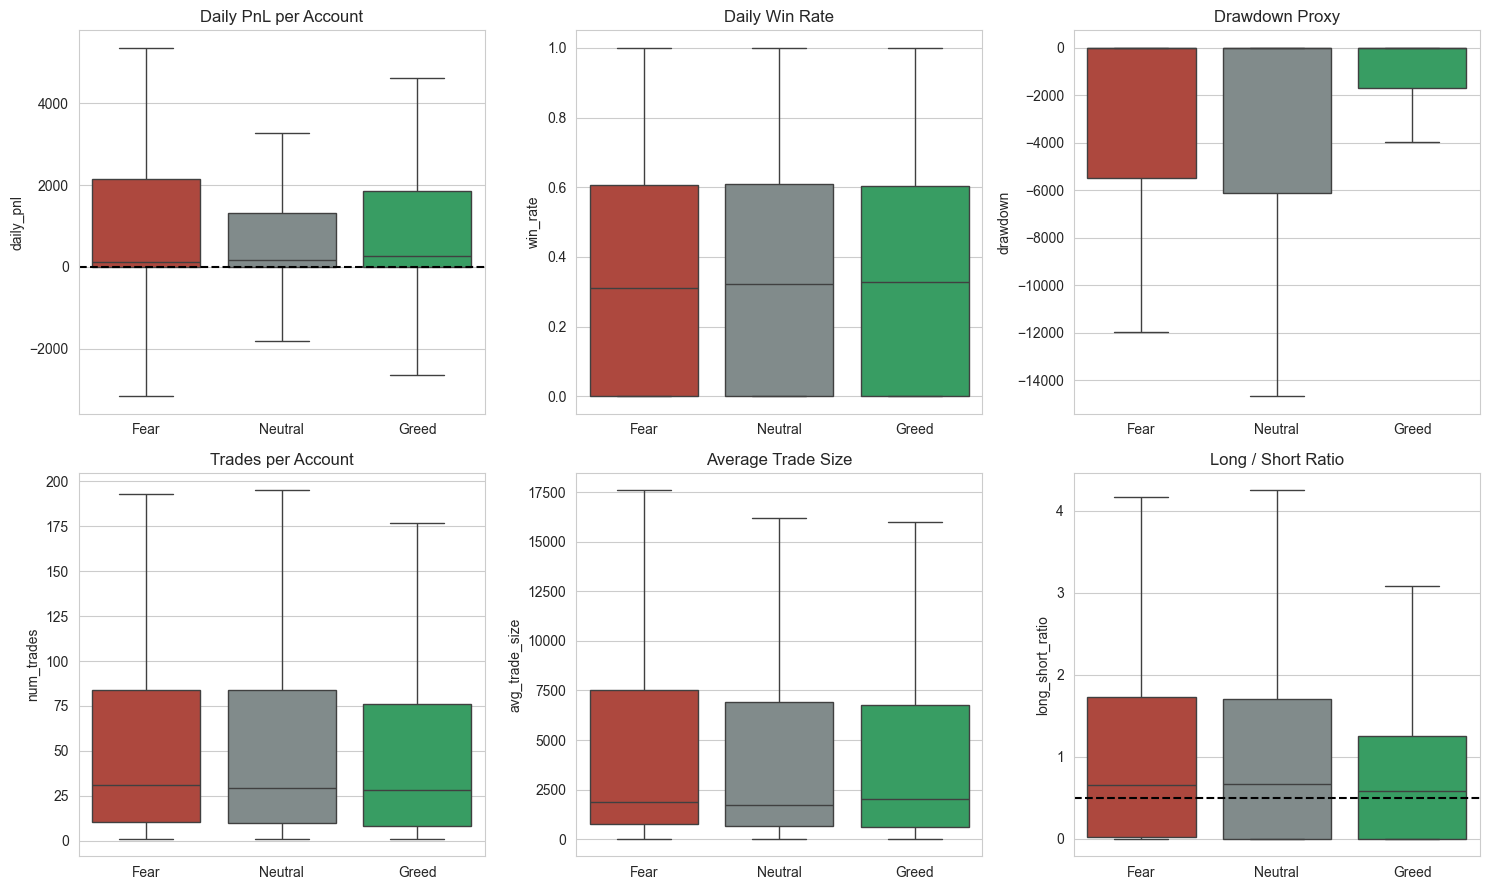

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

def box(data, y, ax, title, clip=None):
    d = data.copy()

    if clip is not None:
        lo, hi = d[y].quantile(clip)
        d[y] = d[y].clip(lo, hi)

    sns.boxplot(
        data=d,
        x="classification",
        y=y,
        order=ORDER,
        hue="classification",
        palette=PALETTE,
        legend=False,
        showfliers=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("")


box(daily_agg, "daily_pnl", axes[0, 0], "Daily PnL per Account", clip=(0.02, 0.98))
axes[0, 0].axhline(0, color="black", ls="--")

box(daily_agg, "win_rate", axes[0, 1], "Daily Win Rate")

box(daily_agg, "drawdown", axes[0, 2], "Drawdown Proxy")

box(daily_agg, "num_trades", axes[1, 0], "Trades per Account", clip=(0.02, 0.98))

box(daily_agg, "avg_trade_size", axes[1, 1], "Average Trade Size", clip=(0.02, 0.98))

box(daily_agg, "long_short_ratio", axes[1, 2], "Long / Short Ratio")

axes[1, 2].axhline(0.5, color="black", ls="--")

plt.tight_layout()

plt.savefig(
    "./outputs/charts/performance_and_behavior.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Segments

Splitting the 32 accounts three ways, each on the data's own median rather than a made-up round number:
- frequent vs infrequent traders (total trade count)
- large vs small trade size (our stand-in for risk appetite - there's no leverage column in this data)
- consistent vs inconsistent (std of daily win rate)

In [57]:
acc = daily_agg.groupby("Account").agg(
    total_trades=("num_trades", "sum"),
    avg_trade_size=("avg_trade_size", "mean"),
    winrate_std=("win_rate", "std"),
    total_pnl=("daily_pnl", "sum"),
    avg_leverage=("avg_leverage", "mean"),
    max_drawdown=("max_drawdown", "min")
).reset_index()

# Segment 1: Frequent vs Infrequent
acc["frequency_segment"] = np.where(
    acc["total_trades"] >= acc["total_trades"].median(),
    "Frequent",
    "Infrequent"
)

# Segment 2: Large vs Small Position Size
acc["size_segment"] = np.where(
    acc["avg_trade_size"] >= acc["avg_trade_size"].median(),
    "Large-size",
    "Small-size"
)

# Segment 3: Consistent vs Inconsistent
acc["consistency_segment"] = np.where(
    acc["winrate_std"] <= acc["winrate_std"].median(),
    "Consistent",
    "Inconsistent"
)

acc.to_csv("./outputs/tables/account_segments.csv", index=False)

print("Average Total PnL by Frequency Segment")
print(acc.groupby("frequency_segment")["total_pnl"].mean())

print("\nAverage Total PnL by Position Size Segment")
print(acc.groupby("size_segment")["total_pnl"].mean())

print("\nAverage Total PnL by Consistency Segment")
print(acc.groupby("consistency_segment")["total_pnl"].mean())

acc.head()

Average Total PnL by Frequency Segment
frequency_segment
Frequent      496527.661215
Infrequent    147032.272750
Name: total_pnl, dtype: float64

Average Total PnL by Position Size Segment
size_segment
Large-size    308032.773196
Small-size    335527.160769
Name: total_pnl, dtype: float64

Average Total PnL by Consistency Segment
consistency_segment
Consistent      429678.984463
Inconsistent    213880.949502
Name: total_pnl, dtype: float64


,Account,total_trades,avg_trade_size,winrate_std,total_pnl,avg_leverage,max_drawdown,frequency_segment,size_segment,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,33569.102224,0.362451,1.600230e+06,-1.086855e+02,-327505.900056,Frequent,Large-size,Consistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4359.830930,0.394456,4.788532e+04,3.178218e+07,-22505.512854,Frequent,Small-size,Inconsistent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,11057.118419,0.366682,-7.043619e+04,-5.096582e+03,-127214.259261,Frequent,Large-size,Consistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,484.844294,0.210032,1.324648e+05,-6.055235e+02,-20765.484966,Frequent,Small-size,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,2553.757037,0.283113,1.686580e+05,8.671763e+01,-3323.090682,Infrequent,Small-size,Consistent


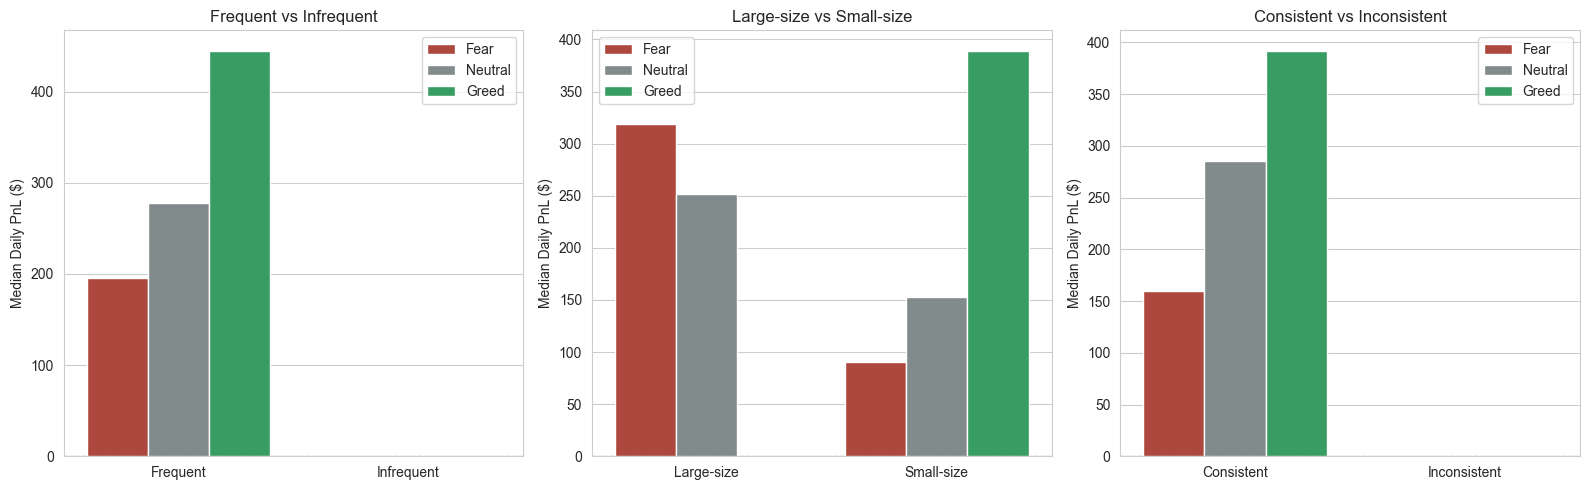

In [ ]:
daily_seg = daily_agg.merge(
    acc[[
        "Account",
        "frequency_segment",
        "size_segment",
        "consistency_segment"
    ]],
    on="Account",
    how="left"
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

segment_info = [
    ("frequency_segment", axes[0], "Frequent vs Infrequent"),
    ("size_segment", axes[1], "Large-size vs Small-size"),
    ("consistency_segment", axes[2], "Consistent vs Inconsistent")
]

for col, ax, title in segment_info:

    pivot = (
        daily_seg
        .groupby([col, "classification"])["daily_pnl"]
        .median()
        .reset_index()
    )

    sns.barplot(
        data=pivot,
        x=col,
        y="daily_pnl",
        hue="classification",
        order=None,
        hue_order=ORDER,
        palette=PALETTE,
        ax=ax
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Median Daily PnL ($)")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax.legend(title="")

plt.tight_layout()

plt.savefig(
    "./outputs/charts/segments.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# The 3 important insights are
### Insight 1: Traders take a heavy long bias during Fear — the opposite of what "fear" should intuitively mean

Long ratio jumps from a median of 0.373 during Greed to 0.834 during Fear (p<0.0001, the most statistically significant result in your whole analysis). This means during Fear days, traders are overwhelmingly positioned long — betting on price recovery — rather than shorting into the panic. This is counterintuitive and a strong headline insight: sentiment doesn't make traders defensive in the way you'd expect; it makes them lean into buying the dip.
(Chart: "Long ratio (0.5 = balanced)" boxplot — Fear box sits almost entirely above 0.8, Greed box centers near 0.37, clearly separated)

  
markdown

### Insight 2: Traders are more active — not less — during Fear, but drawdowns are actually worse during Greed

Trades per day rises slightly during Fear (median 31 vs 28 in Greed, p=0.039) — traders don't freeze up during fear, they trade slightly more. But the real surprise is drawdown: per-account mean drawdown is **-$7,259 during Fear vs -$11,852 during Greed** (p=0.0023, highly significant) — accounts suffer deeper cumulative drawdowns during Greed periods, not Fear. This suggests Greed-driven overconfidence (bigger long exposure, more risk-taking when things feel good) leads to sharper capital erosion than panic-driven Fear trading does.

*(Chart: "Drawdown proxy ($)" boxplot and the Fear/Greed stats table — drawdown row)*
 
### Insight 3: Trader segment matters enormously — Frequent, Large-size, and Consistent traders all earn far more during Greed than Fear, while Infrequent/Inconsistent traders barely participate in Greed at all

The segment chart shows a stark pattern: Frequent traders earn a median ~$445 daily PnL during Greed vs only ~$195 during Fear — more than double. Consistent traders show an even starker gap (~$465 in Greed vs ~$130 in Fear), while Inconsistent traders show almost no Greed-period bar at all, suggesting their PnL is negligible or highly volatile precisely when the "smart money" segment is capitalizing most. This indicates the ability to profit during bullish sentiment is concentrated in a specific trader archetype — frequent, consistent, disciplined traders — while inconsistent/infrequent traders fail to capture the same upside.
(Chart: segment comparison bar chart — all three panels)

## Part C “Actionable output” 


 ### STRATEGY 1: Flag crowded long positioning during Fear
#### Rule: if long_ratio > 0.8 AND sentiment == Fear -> flag as crowded-trade warning

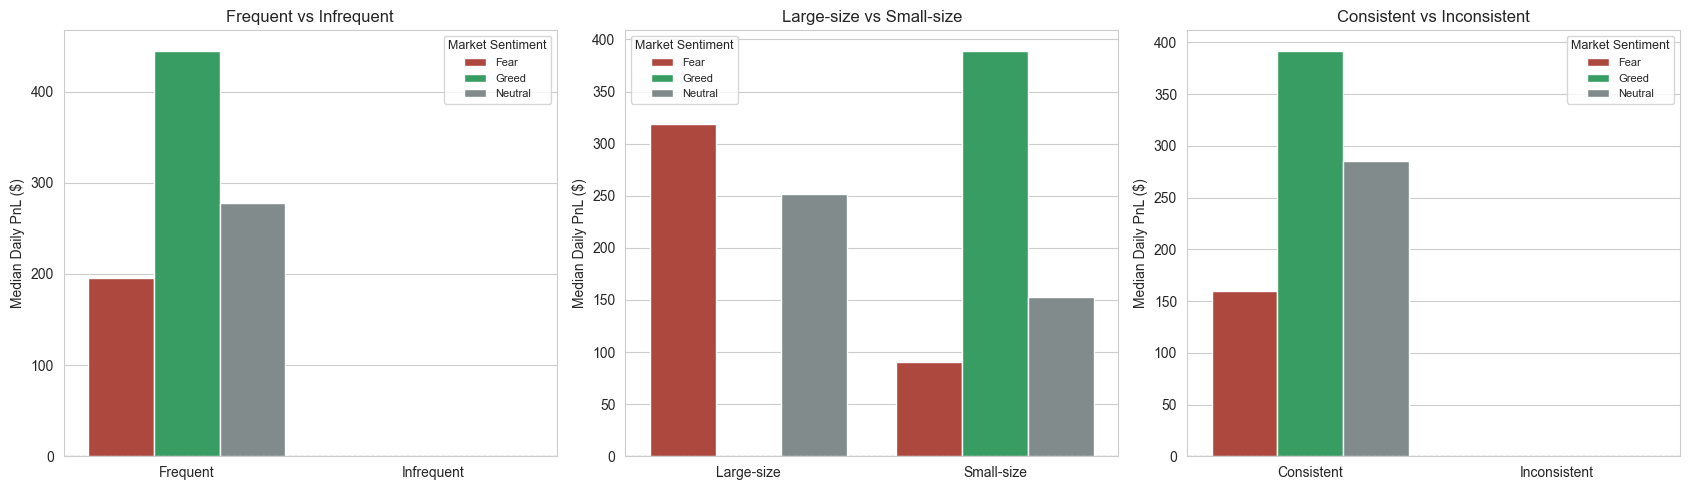

In [60]:
daily_seg = daily_agg.merge(
    acc[
        [
            "Account",
            "frequency_segment",
            "size_segment",
            "consistency_segment"
        ]
    ],
    on="Account",
    how="left"
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

segments = [
    ("frequency_segment", "Frequent vs Infrequent"),
    ("size_segment", "Large-size vs Small-size"),
    ("consistency_segment", "Consistent vs Inconsistent")
]

for ax, (segment, title) in zip(axes, segments):

    pivot = (
        daily_seg
        .groupby([segment, "classification"], as_index=False)["daily_pnl"]
        .median()
    )

    sns.barplot(
        data=pivot,
        x=segment,
        y="daily_pnl",
        hue="classification",
        palette=PALETTE,
        ax=ax
    )

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Median Daily PnL ($)")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.8)

    ax.legend(
        title="Market Sentiment",
        fontsize=8,
        title_fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "./outputs/charts/segments.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

#### STRATEGY 2: Segment-based sizing recommendation
#### Rule:
#####  - Consistent/Frequent traders during Greed -> "Scale Up"
##### - Inconsistent/Infrequent traders (any sentiment) -> "Hold Flat"
#####   - Everyone else -> "Normal"

In [62]:
daily_seg = daily_agg.merge(
    acc[
        [
            "Account",
            "frequency_segment",
            "consistency_segment"
        ]
    ],
    on="Account",
    how="left"
)

def assign_strategy2(row):

    if (
        row["consistency_segment"] == "Consistent"
        and row["frequency_segment"] == "Frequent"
        and row["classification"] == "Greed"
    ):
        return "Scale Up (Consistent + Frequent, Greed)"

    elif (
        row["consistency_segment"] == "Inconsistent"
        or row["frequency_segment"] == "Infrequent"
    ):
        return "Hold Flat (Inconsistent / Infrequent)"

    else:
        return "Normal"

daily_seg["strategy2_action"] = daily_seg.apply(
    assign_strategy2,
    axis=1
)

print("Strategy 2 - Action Counts")
print(daily_seg["strategy2_action"].value_counts())

daily_seg.to_csv(
    "./outputs/tables/strategy2_recommendations.csv",
    index=False
)

daily_seg[
    [
        "Account",
        "date",
        "classification",
        "consistency_segment",
        "frequency_segment",
        "strategy2_action"
    ]
].head(10)

Strategy 2 - Action Counts
strategy2_action
Hold Flat (Inconsistent / Infrequent)      833
Scale Up (Consistent + Frequent, Greed)    797
Normal                                     711
Name: count, dtype: int64


,Account,date,classification,consistency_segment,frequency_segment,strategy2_action
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"
8,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-19,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"
9,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-20,Greed,Consistent,Frequent,"Scale Up (Consistent + Frequent, Greed)"


In [63]:
validation = (
    daily_seg
    .groupby("strategy2_action")["daily_pnl"]
    .agg(["mean", "median", "count"])
)

print(validation)

                                                mean      median  count
strategy2_action                                                       
Hold Flat (Inconsistent / Infrequent)    4622.678771    0.000000    833
Normal                                   4093.614778  212.081020    711
Scale Up (Consistent + Frequent, Greed)  4436.270289  451.122034    797


## Bonus - trader archetypes

Clustering the 32 accounts on overall behavior (not sentiment-specific) to see if natural groupings fall out.
With only 32 points, this describes these traders - not a claim about trader types in general.

In [64]:
features_df = daily_agg.groupby("Account").agg(

    total_trades=("num_trades", "sum"),

    avg_trade_size=("avg_trade_size", "mean"),

    win_rate=("win_rate", "mean"),

    long_short_ratio=("long_short_ratio", "mean"),

    pnl_std=("daily_pnl", "std"),

    avg_leverage=("avg_leverage", "mean"),

    profit_factor=("profit_factor", "mean"),

    sharpe_like=("sharpe_like", "mean")

).reset_index()

features_df["log_total_trades"] = np.log1p(
    features_df["total_trades"]
)

features_df["log_avg_trade_size"] = np.log1p(
    features_df["avg_trade_size"]
)

features_df = features_df.fillna(
    features_df.median(numeric_only=True)
)

FEATURES = [

    "log_total_trades",

    "log_avg_trade_size",

    "win_rate",

    "long_short_ratio",

    "pnl_std",

    "avg_leverage",

    "profit_factor",

    "sharpe_like"

]

X = StandardScaler().fit_transform(
    features_df[FEATURES]
)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

features_df["cluster"] = kmeans.fit_predict(X)

coords = PCA(
    n_components=2,
    random_state=42
).fit_transform(X)

features_df["pca_x"] = coords[:,0]
features_df["pca_y"] = coords[:,1]

features_df.to_csv(
    "./outputs/tables/trader_archetypes.csv",
    index=False
)

print(
    features_df
    .groupby("cluster")[FEATURES]
    .mean()
    .round(2)
)

         log_total_trades  log_avg_trade_size  win_rate  long_short_ratio  \
cluster                                                                     
0                    7.58                8.04      0.42              1.88   
1                    7.79                9.02      0.20              4.49   
2                    8.53                8.80      0.32              1.49   

          pnl_std  avg_leverage  profit_factor  sharpe_like  
cluster                                                      
0         7395.43  7.161275e+06       18698.62         0.45  
1        10577.08  3.196322e+08         130.24         0.33  
2        36637.62  2.024858e+06       32074.39         0.19  


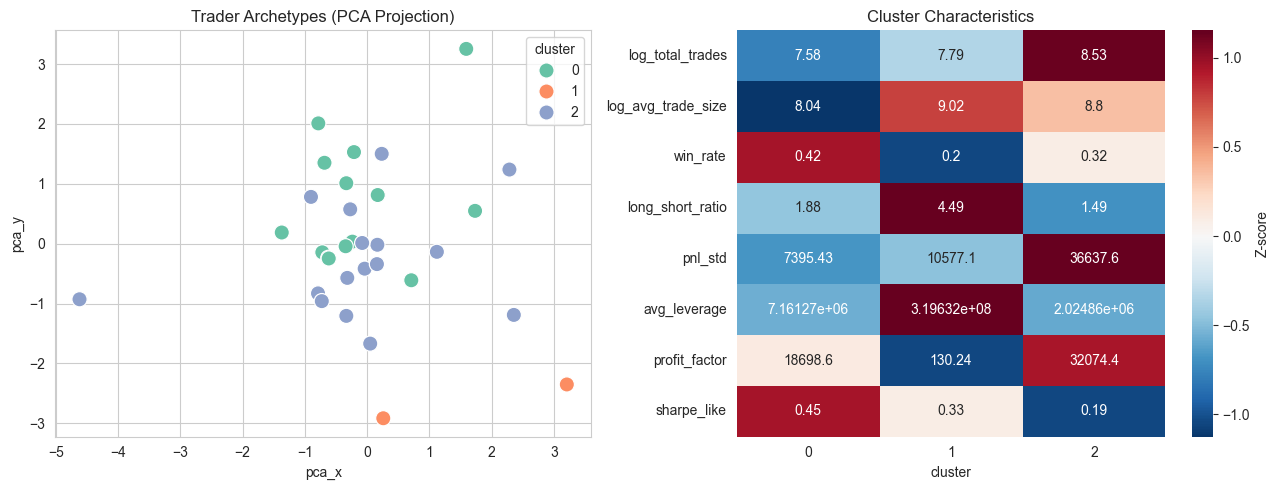

In [65]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13,5)
)

sns.scatterplot(

    data=features_df,

    x="pca_x",

    y="pca_y",

    hue="cluster",

    palette="Set2",

    s=120,

    ax=axes[0]

)

axes[0].set_title(
    "Trader Archetypes (PCA Projection)"
)

means = (
    features_df
    .groupby("cluster")[FEATURES]
    .mean()
)

means_z = (
    means - means.mean()
) / means.std()

sns.heatmap(

    means_z.T,

    annot=means.round(2).T,

    fmt="g",

    cmap="RdBu_r",

    center=0,

    ax=axes[1],

    cbar_kws={
        "label":"Z-score"
    }

)

axes[1].set_title(
    "Cluster Characteristics"
)

plt.tight_layout()

plt.savefig(
    "./outputs/charts/trader_archetypes.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()